<a href="https://colab.research.google.com/github/Mliaqat/Breast-Cancer-Prediction-CNN-MODEL/blob/main/Fyp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Run this code to mount google drive, so that you can have access to the storage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls

Breastcancerdataset  drive  sample_data


In [ ]:
#Run this code to unzip the uploaded dataset file on your google drive
!unzip -q /content/drive/MyDrive/Breastcancerdataset.zip

replace Breastcancerdataset/Test/Bening/bening (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
#Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Import Image Data Generator, which allow us to create data generator for images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#Define Parameters for Model Training
imgSize = 224 #Set Image size to be used as model input
imgChannel = 3 #Set no. of channel in image i.e. 1 if grayscale, 3 if RGB
batch_size = 32 #Set number of images to be used as a set of model training/validation/testing
eps = 50 #Set number of epoches to train the model

# Create an Image Data Generator
input_imgen = ImageDataGenerator(rotation_range=0, width_shift_range=0.0,
                                  height_shift_range=0.0, shear_range=0.0, zoom_range=0.0,
                                  fill_mode='nearest', rescale = 1./255,
                                  validation_split=0.1)

trainDir = '/content/Breastcancerdataset/Train' #Specify path of training data directory
testDir = '/content/Breastcancerdataset/Test' #Specify path of testing data directory

#Tell Image generator to load data from given directory and preprocess data with the mentioned properties

print('Training Dataset:')
trainGen = input_imgen.flow_from_directory(
      directory = trainDir, #Path to directory
      target_size = (imgSize,imgSize), #Resize the images resolution to the desired size
      color_mode = 'rgb', #Specify color mode i.e. RGB or Grayscale image
      class_mode = 'binary', #Specify type of output, i.e. Binary for 2 classes, Categorical for more than 2 classes
      batch_size = batch_size, #Specify batch size to be used
      shuffle=True, #Set whether to shuffle dataset after every epoch
      subset='training', #Specifiy the set of dataset
      classes=["Benign","Malignant"]) #Specify which classes should be considered in generator

print('\nValidation Dataset:')
validGen = input_imgen.flow_from_directory(
      directory = trainDir, #Path to directory
      target_size = (imgSize,imgSize), #Resize the images resolution to the desired size
      color_mode = 'rgb', #Specify color mode i.e. RGB or Grayscale image
      class_mode = 'binary', #Specify type of output, i.e. Binary for 2 classes, Categorical for more than 2 classes
      batch_size = batch_size, #Specify batch size to be used
      shuffle=True, #Set whether to shuffle dataset after every epoch
      subset='validation', #Specifiy the set of dataset
      classes=["Bening","Malignant"]) #Specify which classes should be considered in generator

print('\nTest Dataset:')
testGen = input_imgen.flow_from_directory(
      directory = testDir, #Path to directory
      target_size = (imgSize,imgSize), #Resize the images resolution to the desired size
      color_mode = 'rgb', #Specify color mode i.e. RGB or Grayscale image
      class_mode = 'binary', #Specify type of output, i.e. Binary for 2 classes, Categorical for more than 2 classes
      batch_size = batch_size, #Specify batch size to be used
      shuffle=False, #Set whether to shuffle dataset after every epoch
      #subset='validation', #Specifiy the set of dataset
      classes=["Bening","Malignant"]) #Specify which classes should be considered in generator

#Run this code to check the values assigned to each class
label_map = (trainGen.class_indices)
print('\nValue assigned to each class: ',label_map)



Training Dataset:
Found 1328 images belonging to 2 classes.

Validation Dataset:
Found 101 images belonging to 2 classes.

Test Dataset:
Found 369 images belonging to 2 classes.

Value assigned to each class:  {'Benign': 0, 'Malignant': 1}


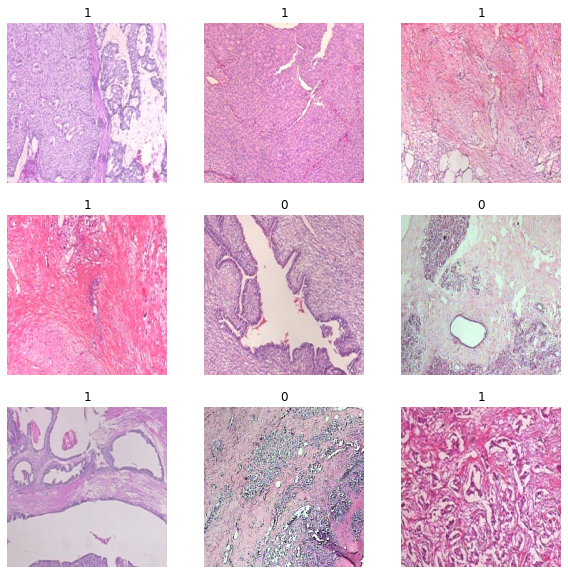

In [ ]:
#Run this code to pick one batch from the training dataset
images,labels = next(trainGen)

#Display some glimpse of the picked batch data
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis("off")

In [ ]:
# This code generate model using sequential model technique
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(imgSize,imgSize,imgChannel), padding="same"))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D(pool_size=(2, 2), padding="same"))
model.add(Conv2D( 64, kernel_size=(3, 3), activation='relu', padding="same"))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D(pool_size=(2, 2), padding="same"))
#Global Average Pooling (GAP) is a pooling operation designed to replace fully connected layers in classical CNNs
#In GAP, we take average value of the last feature map and flatten it into 1 dimensional hot-vector
model.add(GlobalAveragePooling2D()) 
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 224, 224, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 224, 224, 64)      18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 64)      0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 112, 112, 64)      36928     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 112, 112, 128)     73856     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 128)       0         
_________________________________________________________________
global_average_pooling2d (Gl (None, 128)               0

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [ ]:
history = model.fit(trainGen, 
                    batch_size=batch_size, 
                    epochs=20, 
                    shuffle=True, 
                    validation_data=validGen)

Epoch 1/20
42/42 [==============================] - 61s 632ms/step - loss: 0.6238 - accuracy: 0.6807 - val_loss: 0.3115 - val_accuracy: 1.0000
Epoch 2/20
42/42 [==============================] - 24s 567ms/step - loss: 0.5796 - accuracy: 0.7199 - val_loss: 0.3235 - val_accuracy: 0.9901
Epoch 3/20
42/42 [==============================] - 24s 568ms/step - loss: 0.5595 - accuracy: 0.7402 - val_loss: 0.5362 - val_accuracy: 0.8812
Epoch 4/20
42/42 [==============================] - 24s 563ms/step - loss: 0.5500 - accuracy: 0.7440 - val_loss: 0.4426 - val_accuracy: 0.9109
Epoch 5/20
42/42 [==============================] - 24s 559ms/step - loss: 0.5383 - accuracy: 0.7651 - val_loss: 0.1813 - val_accuracy: 0.9901
Epoch 6/20
42/42 [==============================] - 24s 563ms/step - loss: 0.5353 - accuracy: 0.7696 - val_loss: 0.2068 - val_accuracy: 1.0000
Epoch 7/20
42/42 [==============================] - 24s 560ms/step - loss: 0.5322 - accuracy: 0.7643 - val_loss: 0.2080 - val_accuracy: 0.9901

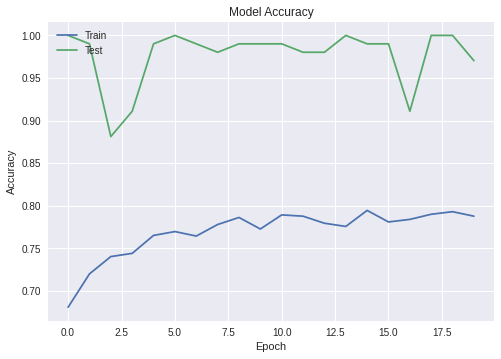

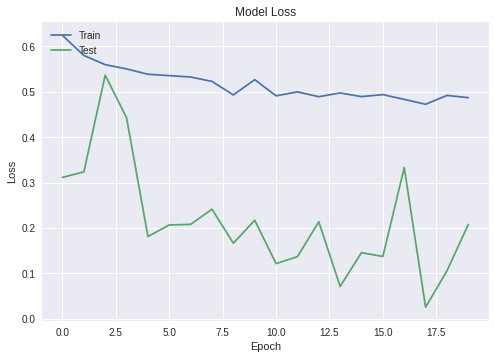

In [ ]:
plt.style.use('seaborn')

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# summarize history for loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/FYPMODEL/custom_model_50epoch.h5')

In [ ]:
#Use the trained model to make prediction on test dataset
y_pred = model.predict(testGen,verbose=1)

#Run this line to evaluate the model accuracy and loss on test dataset
b = model.evaluate(testGen)
c = model.evaluate(validGen)


4/4 [==============================] - 1s 305ms/step - loss: 0.2079 - accuracy: 0.9703


In [ ]:
#Apply threshold of 50% to round the results values
y_pred[y_pred >= 0.5] = 1
y_pred[y_pred < 0.5] = 0

#Convert the array results to 1 dimensional hot vector, so that it can be used to compare with test dataset ground truth labels
y_pred = y_pred.flatten()

#Get the labels of the ground truth test dataset
y_true = testGen.classes

#Evaluate the model performance using metrics and display results
print('\nConfusion Matrix')
print(confusion_matrix(y_true, y_pred))
print('\nClassification Report')
print(classification_report(y_true, y_pred, digits=4))


Confusion Matrix
[[ 69  45]
 [  9 246]]

Classification Report
              precision    recall  f1-score   support

           0     0.8846    0.6053    0.7188       114
           1     0.8454    0.9647    0.9011       255

    accuracy                         0.8537       369
   macro avg     0.8650    0.7850    0.8099       369
weighted avg     0.8575    0.8537    0.8448       369



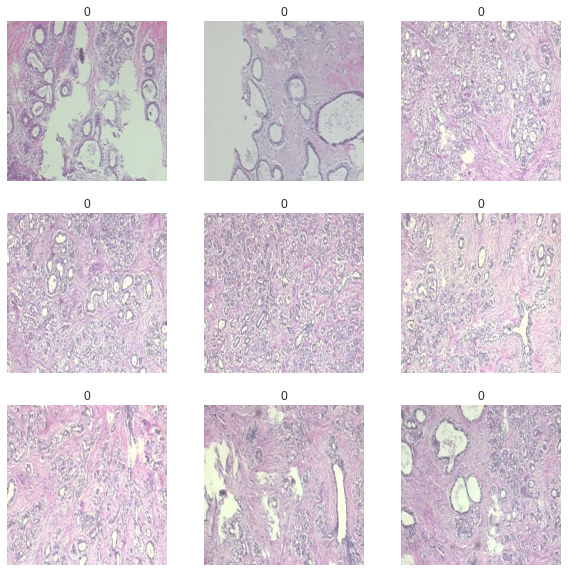

In [ ]:
#Pick one batch of the test dataset
images,labels = next(testGen)

y_pred_batch = model.predict(images)

#Show some glimpse of the model prediction along with input test images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(int(y_pred_batch[i]))
    plt.axis("off")

In [ ]:
#Import state-of-the-art ResNet50 architecture and input data preprocessing function
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

**Apply ResNet50**


In [ ]:
ResNet = ResNet50(weights=None, include_top = False,input_shape=(224,224,3))
ResNet.summary()

Model: "resnet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1_conv[0][0]                 
___________________________________________________________________________________________

In [ ]:
#Modify ResNet50 architecture according to our requirement (Cat, Dog Classification)
x =  ResNet.output
GAP = GlobalAveragePooling2D()(x)
drop = Dropout(0.2)(GAP)
out = Dense(1, activation='sigmoid')(drop)

ResNet = Model(inputs = ResNet.input, outputs = out)
ResNet.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1_conv[0][0]                 
______________________________________________________________________________________________

In [ ]:
ResNet.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [ ]:
history = ResNet.fit(trainGen, 
                    batch_size=batch_size,
                    epochs=10, 
                    shuffle=True,
                    validation_data=validGen)

Epoch 1/10
42/42 [==============================] - 51s 861ms/step - loss: 1.0092 - accuracy: 0.7327 - val_loss: 0.1226 - val_accuracy: 1.0000
Epoch 2/10
42/42 [==============================] - 33s 779ms/step - loss: 0.6192 - accuracy: 0.7673 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 3/10
42/42 [==============================] - 33s 777ms/step - loss: 0.5155 - accuracy: 0.7877 - val_loss: 2.8745e-08 - val_accuracy: 1.0000
Epoch 4/10
42/42 [==============================] - 33s 779ms/step - loss: 0.5421 - accuracy: 0.7846 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 5/10
42/42 [==============================] - 33s 775ms/step - loss: 0.4398 - accuracy: 0.8200 - val_loss: 328.0593 - val_accuracy: 0.0099
Epoch 6/10
42/42 [==============================] - 33s 776ms/step - loss: 0.4738 - accuracy: 0.7959 - val_loss: 214.6035 - val_accuracy: 0.0000e+00
Epoch 7/10
42/42 [==============================] - 33s 778ms/step - loss: 0.4588 - accuracy: 0.8133 - val_loss: 0.1375 - 

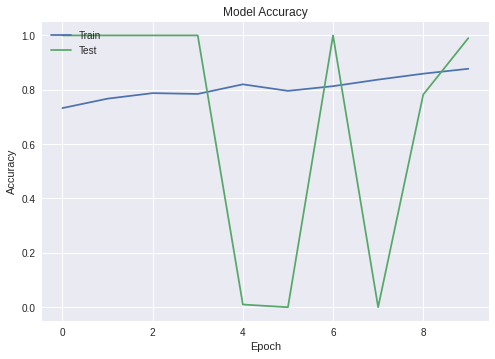

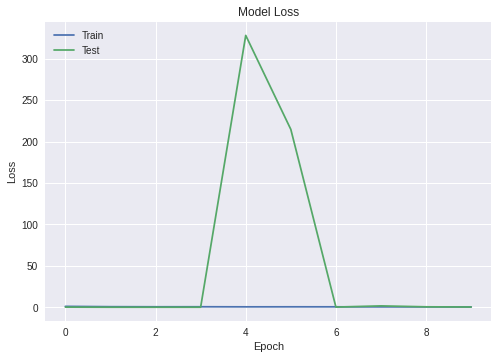

In [ ]:
plt.style.use('seaborn')

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# summarize history for loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
#Use the trained model to predict the results on test dataset
y_pred = ResNet.predict(testGen,verbose=1)

#Run this line to evaluate the model accuracy and loss on test dataset
b = ResNet.evaluate(testGen)


12/12 [==============================] - 7s 531ms/step - loss: 0.7895 - accuracy: 0.6558


In [ ]:
#Apply threshold of 50% to round the results values
y_pred[y_pred >= 0.5] = 1
y_pred[y_pred < 0.5] = 0

#Convert the array results to 1 dimensional hot vector, so that it can be used to compare with test dataset ground truth labels
y_pred = y_pred.flatten()

#Get the labels of the ground truth test dataset
y_true = testGen.classes

#Evaluate the model performance using metrics and display results
print('\nConfusion Matrix')
print(confusion_matrix(y_true, y_pred))
print('\nClassification Report')
print(classification_report(y_true, y_pred, digits=4))


Confusion Matrix
[[  0 114]
 [ 13 242]]

Classification Report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       114
           1     0.6798    0.9490    0.7921       255

    accuracy                         0.6558       369
   macro avg     0.3399    0.4745    0.3961       369
weighted avg     0.4698    0.6558    0.5474       369



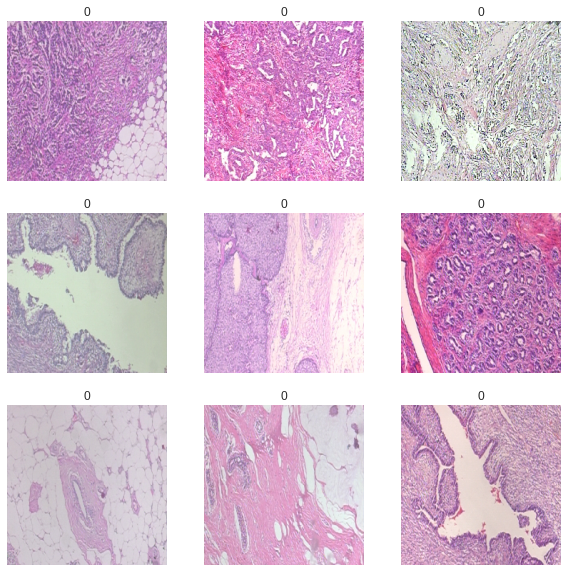

In [ ]:
#Run this code to pick one batch from the training dataset
images,labels = next(trainGen)
y_pred_batch = ResNet.predict(images)

#Display some glimpse of the picked batch data
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])#.astype(np.uint8))
    plt.title(int(y_pred_batch[i]))
    plt.axis("off")